In [1]:
import csv
import copy 
import functools 
from collections import namedtuple 
from pathlib import Path 


import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import SimpleITK as sitk 

DATA_DIR = Path("../data/luna")


In [2]:
annotations_df = pd.read_csv(DATA_DIR / "annotations.csv")
candidates_df = pd.read_csv(DATA_DIR / "candidates.csv")

print(f"annotations.csv: {len(annotations_df)} linhas")
print(f"candidates.csv: {len(candidates_df)} linhas")
print(f"Candidatos positivos: {candidates_df['class'].sum()}")

annotations.csv: 1186 linhas
candidates.csv: 551065 linhas
Candidatos positivos: 1351


* is_nodule -- se é nodulo ou não (booleano)
* diameter_mn -- diametro em mm (0.0 para não nodulos)
* series_uid -- identificador do CT scan
* center_xyz -- coodernadas (x,y,z) em milimetros

In [7]:
CandidateInfo = namedtuple(
    "CandidateInfo",
    "is_nodule, diameter_mm, series_uid, center_xyz",
)

In [4]:
diameter_dict = {}
with open(DATA_DIR / "annotations.csv") as f:
    for row in list(csv.reader(f))[1:]:
        series_uid = row[0]
        center_xyz = tuple(float(x) for x in row[1:4])
        diameter_mm = float(row[4])
        diameter_dict.setdefault(series_uid, []).append(
            (center_xyz, diameter_mm)
        )

print(f"Series com anotacoes: {len(diameter_dict)}")
print(f"Total de anotacoes: {sum(len(v) for v in diameter_dict.values())}")

Series com anotacoes: 601
Total de anotacoes: 1186


In [5]:
@functools.lru_cache(1)
def load_candidates(require_on_disk=True):
    mhd_files = list(DATA_DIR.rglob("*.mhd"))
    present_on_disk = {p.stem for p in mhd_files}

    diameter_dict = {}
    with open(DATA_DIR / "annotations.csv") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            center_xyz = tuple(float(x) for x in row[1:4])
            diameter_mm = float(row[4])
            diameter_dict.setdefault(series_uid, []).append(
                (center_xyz, diameter_mm)
            )

    candidates = []
    with open(DATA_DIR / "candidates.csv") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            if require_on_disk and series_uid not in present_on_disk:
                continue

            is_nodule = bool(int(row[4]))
            center_xyz = tuple(float(x) for x in row[1:4])

            candidate_diameter = 0.0
            for ann_xyz, ann_diam in diameter_dict.get(series_uid, []):
                for i in range(3):
                    if abs(center_xyz[i] - ann_xyz[i]) > ann_diam / 4:
                        break
                else:
                    candidate_diameter = ann_diam
                    break

            candidates.append(CandidateInfo(
                is_nodule, candidate_diameter, series_uid, center_xyz
            ))

    candidates.sort(reverse=True)
    return candidates

In [8]:
candidates = load_candidates()
nodules = [c for c in candidates if c.is_nodule]
non_nodules = [c for c in candidates if not c.is_nodule]

print(f"Total de candidatos em disco: {len(candidates)}")
print(f"Nodulos: {len(nodules)}")
print(f"Nao-nodulos: {len(non_nodules)}")
print(f"\nExemplo de nodulo: {nodules[0]}")

Total de candidatos em disco: 551065
Nodulos: 1351
Nao-nodulos: 549714

Exemplo de nodulo: CandidateInfo(is_nodule=True, diameter_mm=32.27003025, series_uid='1.3.6.1.4.1.14519.5.2.1.6279.6001.287966244644280690737019247886', center_xyz=(67.61451718, 85.02525992, -109.8084416))


In [10]:
example_nodule = nodules[0]
series_uid = example_nodule.series_uid

mhd_path = list(DATA_DIR.rglob(f"{series_uid}.mhd"))[0]
ct_mhd = sitk.ReadImage(str(mhd_path))
ct_a = np.array(sitk.GetArrayFromImage(ct_mhd), dtype=np.float32)

print(f"Series UID: ...{series_uid[-20:]}")
print(f"Shape (slices, altura, largura): {ct_a.shape}")
print(f"Spacing (mm por voxel): {ct_mhd.GetSpacing()}")
print(f"Origin (mm): {ct_mhd.GetOrigin()}")

Series UID: ...44280690737019247886
Shape (slices, altura, largura): (123, 512, 512)
Spacing (mm por voxel): (0.8203120231628418, 0.8203120231628418, 2.5)
Origin (mm): (-212.199997, -210.0, -338.0)


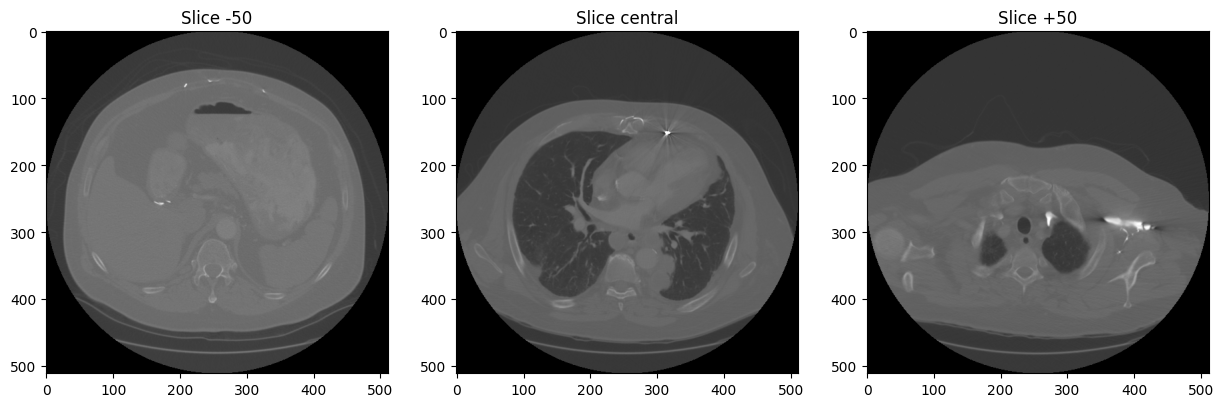

In [11]:
mid = ct_a.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, offset, title in zip(
    axes, [-50, 0, 50],
    ["Slice -50", "Slice central", "Slice +50"]
):
    ax.imshow(ct_a[mid + offset], cmap="gray")
    ax.set_title(title)
plt.show()

In [12]:
IRC = namedtuple("IRC", "index, row, col")
XYZ = namedtuple("XYZ", "x, y, z")

In [13]:
def xyz_to_irc(coord_xyz, origin_xyz, vx_size_xyz, direction_a):
    origin_a = np.array(origin_xyz)
    vx_size_a = np.array(vx_size_xyz)
    coord_a = np.array(coord_xyz)
    cri_a = ((coord_a - origin_a) @ np.linalg.inv(direction_a)) / vx_size_a
    cri_a = np.round(cri_a)
    return IRC(int(cri_a[2]), int(cri_a[1]), int(cri_a[0]))

In [14]:
def irc_to_xyz(coord_irc, origin_xyz, vx_size_xyz, direction_a):
    cri_a = np.array(coord_irc)[::-1]
    origin_a = np.array(origin_xyz)
    vx_size_a = np.array(vx_size_xyz)
    coord_xyz = (direction_a @ (cri_a * vx_size_a)) + origin_a
    return XYZ(*coord_xyz)

In [15]:
origin_xyz = XYZ(*ct_mhd.GetOrigin())
vx_size_xyz = XYZ(*ct_mhd.GetSpacing())
direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)

nodule_irc = xyz_to_irc(
    example_nodule.center_xyz, origin_xyz, vx_size_xyz, direction_a
)
print(f"Nodulo XYZ (mm): {example_nodule.center_xyz}")
print(f"Nodulo IRC (indices): {nodule_irc}")

Nodulo XYZ (mm): (67.61451718, 85.02525992, -109.8084416)
Nodulo IRC (indices): IRC(index=91, row=360, col=341)


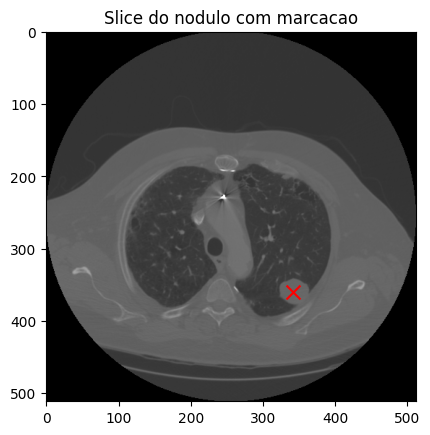

In [16]:
plt.imshow(ct_a[nodule_irc.index], cmap="gray")
plt.scatter(nodule_irc.col, nodule_irc.row, c="red", s=100, marker="x")
plt.title("Slice do nodulo com marcacao")
plt.show()

In [17]:
class CtScan:
    def __init__(self, series_uid):
        mhd_path = list(DATA_DIR.rglob(f"{series_uid}.mhd"))[0]
        ct_mhd = sitk.ReadImage(str(mhd_path))
        self.hu_a = np.array(
            sitk.GetArrayFromImage(ct_mhd), dtype=np.float32
        )
        self.hu_a.clip(-1000, 1000, self.hu_a)

        self.series_uid = series_uid
        self.origin_xyz = XYZ(*ct_mhd.GetOrigin())
        self.vx_size_xyz = XYZ(*ct_mhd.GetSpacing())
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)

In [18]:
def extract_crop(self, center_xyz, crop_size=(32, 48, 48)):
    center_irc = xyz_to_irc(
        center_xyz, self.origin_xyz,
        self.vx_size_xyz, self.direction_a,
    )
    slices = []
    for axis, center_val in enumerate(center_irc):
        start = int(round(center_val - crop_size[axis] / 2))
        end = int(start + crop_size[axis])
        if start < 0:
            start, end = 0, int(crop_size[axis])
        if end > self.hu_a.shape[axis]:
            end = self.hu_a.shape[axis]
            start = int(end - crop_size[axis])
        slices.append(slice(start, end))
    return self.hu_a[tuple(slices)], center_irc

CtScan.extract_crop = extract_crop

In [19]:
@functools.lru_cache(1)
def get_ct(series_uid):
    return CtScan(series_uid)

In [20]:
ct = get_ct(example_nodule.series_uid)
crop, center_irc = ct.extract_crop(example_nodule.center_xyz)

print(f"Shape do crop: {crop.shape}")
print(f"Centro IRC: {center_irc}")
print(f"HU min/max: {crop.min():.0f} / {crop.max():.0f}")

Shape do crop: (32, 48, 48)
Centro IRC: IRC(index=91, row=360, col=341)
HU min/max: -1000 / 954


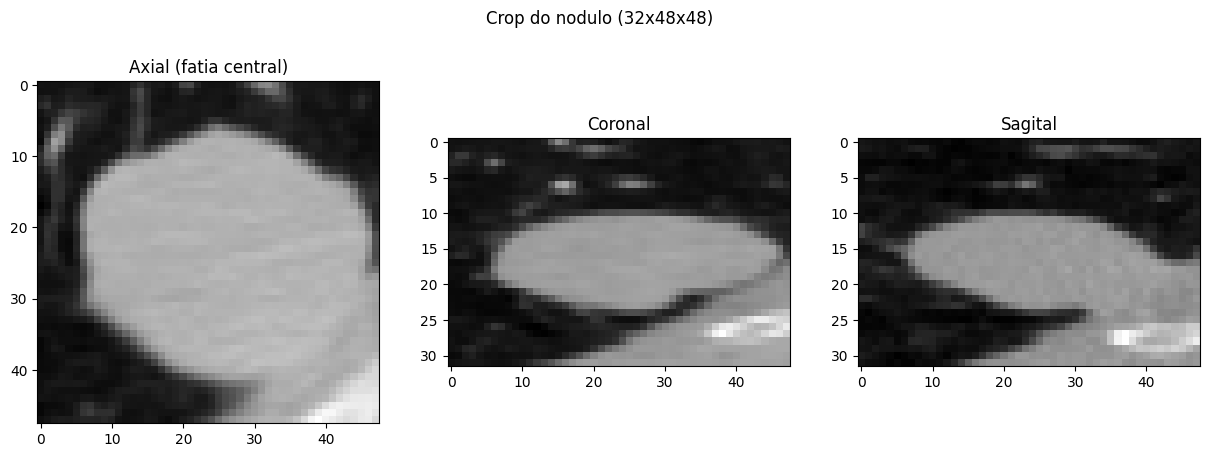

In [21]:
d, h, w = crop.shape

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop[d // 2], cmap="gray")
axes[0].set_title("Axial (fatia central)")
axes[1].imshow(crop[:, h // 2, :], cmap="gray")
axes[1].set_title("Coronal")
axes[2].imshow(crop[:, :, w // 2], cmap="gray")
axes[2].set_title("Sagital")
plt.suptitle(f"Crop do nodulo ({d}x{h}x{w})")
plt.show()

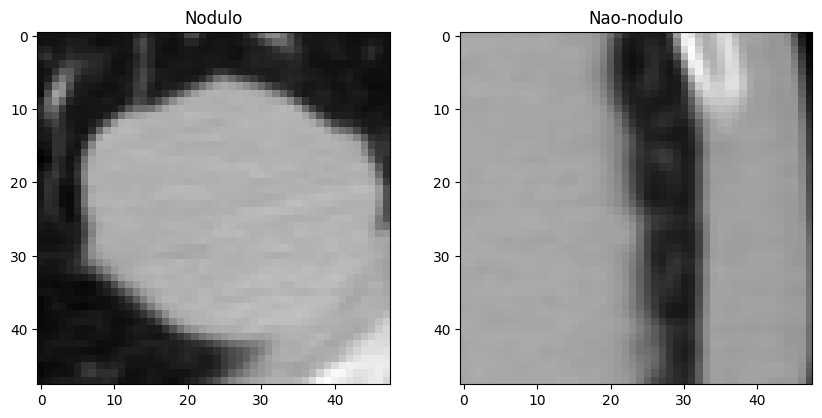

In [22]:
example_non_nodule = non_nodules[0]
ct_neg = get_ct(example_non_nodule.series_uid)
crop_neg, _ = ct_neg.extract_crop(example_non_nodule.center_xyz)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(crop[d // 2], cmap="gray")
axes[0].set_title("Nodulo")
axes[1].imshow(crop_neg[crop_neg.shape[0] // 2], cmap="gray")
axes[1].set_title("Nao-nodulo")
plt.show()

In [23]:
import torch
from torch.utils.data import Dataset, DataLoader

class LunaDataset(Dataset):
    def __init__(self, val_stride=0, is_val=None, series_uid=None):
        self.candidates = copy.copy(load_candidates())
        if series_uid:
            self.candidates = [
                c for c in self.candidates
                if c.series_uid == series_uid
            ]
        if is_val:
            assert val_stride > 0
            self.candidates = self.candidates[::val_stride]
        elif val_stride > 0:
            del self.candidates[::val_stride]

In [24]:
def __len__(self):
    return len(self.candidates)

def __getitem__(self, idx):
    candidate = self.candidates[idx]
    ct = get_ct(candidate.series_uid)
    crop_a, center_irc = ct.extract_crop(candidate.center_xyz)

    crop_t = torch.from_numpy(crop_a).to(torch.float32)
    crop_t = crop_t.unsqueeze(0)
    label_t = torch.tensor(
        [not candidate.is_nodule, candidate.is_nodule],
        dtype=torch.long,
    )
    return crop_t, label_t, candidate.series_uid, torch.tensor(center_irc)

LunaDataset.__len__ = __len__
LunaDataset.__getitem__ = __getitem__

In [25]:
ds = LunaDataset()
crop_t, label_t, uid, center_t = ds[0]

print(f"Dataset: {len(ds)} candidatos")
print(f"crop_t shape: {crop_t.shape}")
print(f"label_t: {label_t}")
print(f"series_uid: ...{uid[-20:]}")
print(f"center_irc: {center_t}")

Dataset: 551065 candidatos
crop_t shape: torch.Size([1, 32, 48, 48])
label_t: tensor([0, 1])
series_uid: ...44280690737019247886
center_irc: tensor([ 91, 360, 341])


In [26]:
train_ds = LunaDataset(val_stride=10, is_val=False)
val_ds = LunaDataset(val_stride=10, is_val=True)

print(f"Treino: {len(train_ds)} candidatos")
print(f"Validacao: {len(val_ds)} candidatos")

Treino: 495958 candidatos
Validacao: 55107 candidatos


In [27]:
loader = DataLoader(train_ds, batch_size=4, shuffle=True)
batch = next(iter(loader))
crops, labels, uids, centers = batch

print(f"Batch crops: {crops.shape}")
print(f"Batch labels: {labels.shape}")
print(f"Labels: {labels}")

Batch crops: torch.Size([4, 1, 32, 48, 48])
Batch labels: torch.Size([4, 2])
Labels: tensor([[1, 0],
        [1, 0],
        [1, 0],
        [1, 0]])


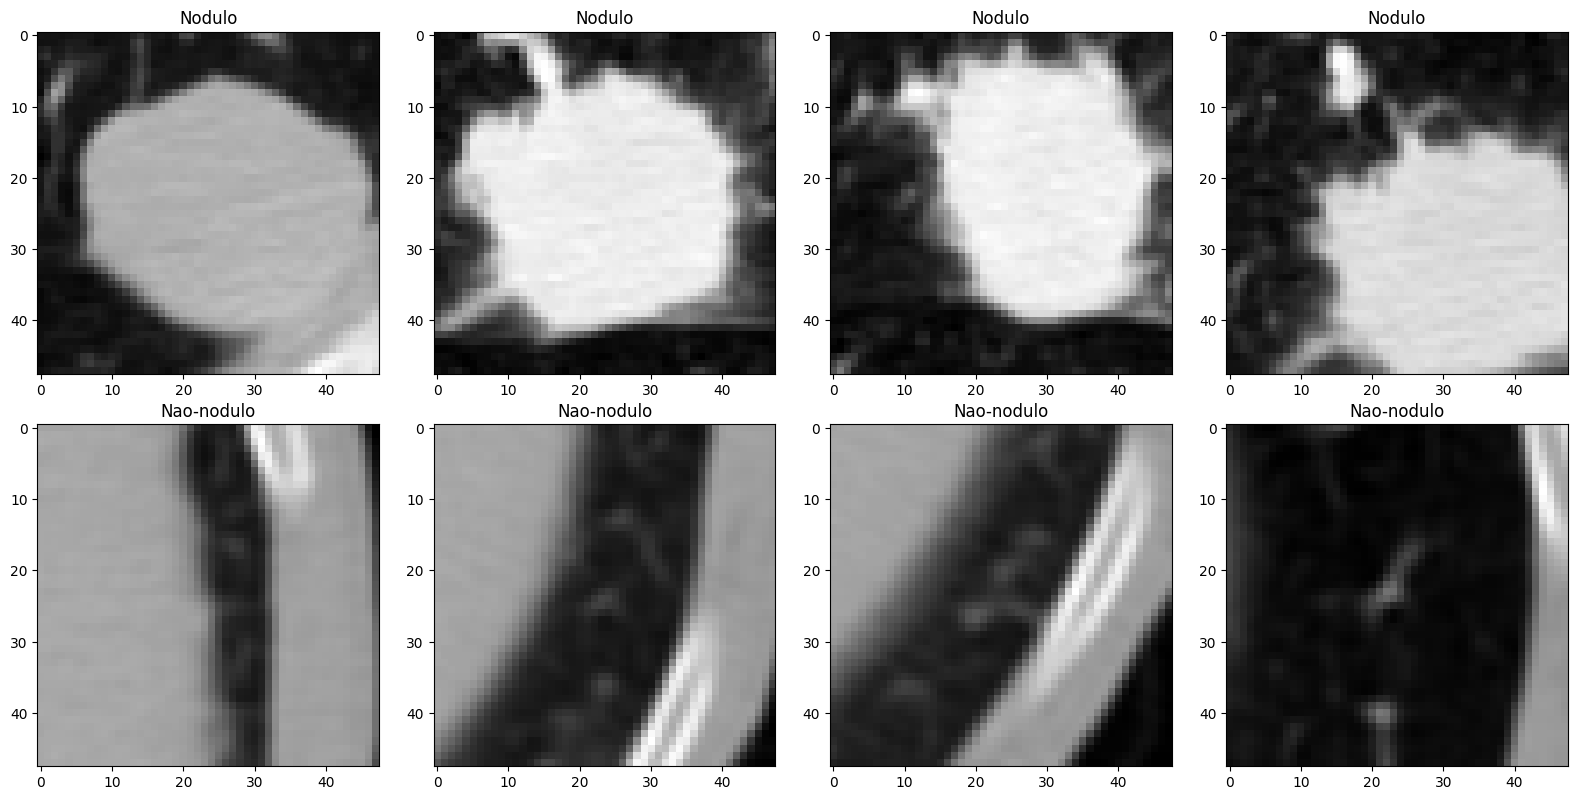

In [28]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    crop_t, _, _, _ = ds[i]
    axes[0, i].imshow(crop_t[0, 16], cmap="gray")
    axes[0, i].set_title("Nodulo")

n_nod = sum(1 for c in ds.candidates if c.is_nodule)
for i in range(4):
    crop_t, _, _, _ = ds[n_nod + i]
    axes[1, i].imshow(crop_t[0, 16], cmap="gray")
    axes[1, i].set_title("Nao-nodulo")

plt.tight_layout()
plt.show()

In [30]:
%%writefile ../src/luna_data.py
"""Modulo de dados LUNA16 - candidatos, CT scans e Dataset PyTorch."""

import copy
import csv
import functools
from collections import namedtuple
from pathlib import Path

import numpy as np
import SimpleITK as sitk
import torch
from torch.utils.data import Dataset

DATA_DIR = Path(__file__).resolve().parent.parent / "data" / "luna"


CandidateInfo = namedtuple(
    "CandidateInfo",
    "is_nodule, diameter_mm, series_uid, center_xyz",
)

IRC = namedtuple("IRC", "index, row, col")
XYZ = namedtuple("XYZ", "x, y, z")


def irc_to_xyz(coord_irc, origin_xyz, vx_size_xyz, direction_a):
    cri_a = np.array(coord_irc)[::-1]
    origin_a = np.array(origin_xyz)
    vx_size_a = np.array(vx_size_xyz)
    coord_xyz = (direction_a @ (cri_a * vx_size_a)) + origin_a
    return XYZ(*coord_xyz)


def xyz_to_irc(coord_xyz, origin_xyz, vx_size_xyz, direction_a):
    origin_a = np.array(origin_xyz)
    vx_size_a = np.array(vx_size_xyz)
    coord_a = np.array(coord_xyz)
    cri_a = ((coord_a - origin_a) @ np.linalg.inv(direction_a)) / vx_size_a
    cri_a = np.round(cri_a)
    return IRC(int(cri_a[2]), int(cri_a[1]), int(cri_a[0]))


@functools.lru_cache(1)
def load_candidates(require_on_disk=True):
    mhd_files = list(DATA_DIR.rglob("*.mhd"))
    present_on_disk = {p.stem for p in mhd_files}

    diameter_dict = {}
    with open(DATA_DIR / "annotations.csv") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            center_xyz = tuple(float(x) for x in row[1:4])
            diameter_mm = float(row[4])
            diameter_dict.setdefault(series_uid, []).append(
                (center_xyz, diameter_mm)
            )

    candidates = []
    with open(DATA_DIR / "candidates.csv") as f:
        for row in list(csv.reader(f))[1:]:
            series_uid = row[0]
            if require_on_disk and series_uid not in present_on_disk:
                continue

            is_nodule = bool(int(row[4]))
            center_xyz = tuple(float(x) for x in row[1:4])

            candidate_diameter = 0.0
            for ann_xyz, ann_diam in diameter_dict.get(series_uid, []):
                for i in range(3):
                    if abs(center_xyz[i] - ann_xyz[i]) > ann_diam / 4:
                        break
                else:
                    candidate_diameter = ann_diam
                    break

            candidates.append(CandidateInfo(
                is_nodule, candidate_diameter, series_uid, center_xyz
            ))

    candidates.sort(reverse=True)
    return candidates


class CtScan:
    def __init__(self, series_uid):
        mhd_path = list(DATA_DIR.rglob(f"{series_uid}.mhd"))[0]
        ct_mhd = sitk.ReadImage(str(mhd_path))
        self.hu_a = np.array(
            sitk.GetArrayFromImage(ct_mhd), dtype=np.float32
        )
        self.hu_a.clip(-1000, 1000, self.hu_a)

        self.series_uid = series_uid
        self.origin_xyz = XYZ(*ct_mhd.GetOrigin())
        self.vx_size_xyz = XYZ(*ct_mhd.GetSpacing())
        self.direction_a = np.array(ct_mhd.GetDirection()).reshape(3, 3)

    def extract_crop(self, center_xyz, crop_size=(32, 48, 48)):
        center_irc = xyz_to_irc(
            center_xyz, self.origin_xyz,
            self.vx_size_xyz, self.direction_a,
        )
        slices = []
        for axis, center_val in enumerate(center_irc):
            start = int(round(center_val - crop_size[axis] / 2))
            end = int(start + crop_size[axis])
            if start < 0:
                start, end = 0, int(crop_size[axis])
            if end > self.hu_a.shape[axis]:
                end = self.hu_a.shape[axis]
                start = int(end - crop_size[axis])
            slices.append(slice(start, end))
        return self.hu_a[tuple(slices)], center_irc


@functools.lru_cache(1)
def get_ct(series_uid):
    return CtScan(series_uid)


class LunaDataset(Dataset):
    def __init__(self, val_stride=0, is_val=None, series_uid=None):
        self.candidates = copy.copy(load_candidates())
        if series_uid:
            self.candidates = [
                c for c in self.candidates
                if c.series_uid == series_uid
            ]
        if is_val:
            assert val_stride > 0
            self.candidates = self.candidates[::val_stride]
        elif val_stride > 0:
            del self.candidates[::val_stride]

    def __len__(self):
        return len(self.candidates)

    def __getitem__(self, idx):
        candidate = self.candidates[idx]
        ct = get_ct(candidate.series_uid)
        crop_a, center_irc = ct.extract_crop(candidate.center_xyz)

        crop_t = torch.from_numpy(crop_a).to(torch.float32)
        crop_t = crop_t.unsqueeze(0)
        label_t = torch.tensor(
            [not candidate.is_nodule, candidate.is_nodule],
            dtype=torch.long,
        )
        return crop_t, label_t, candidate.series_uid, torch.tensor(center_irc)

Overwriting ../src/luna_data.py
